<a href="https://colab.research.google.com/github/emon4075/homlp-emon/blob/master/Chapter%202%20%E2%80%93%20End-to-End%20Machine%20Learning%20Project/Chapter_2_%E2%80%93_End_to_End_Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [439]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Data Loading

In [382]:
url = 'https://github.com/ageron/data/raw/main/housing/housing.csv'
df = pd.read_csv(url)

# Quick Data Inspection

In [383]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [384]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [385]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [386]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


# Explore Insights

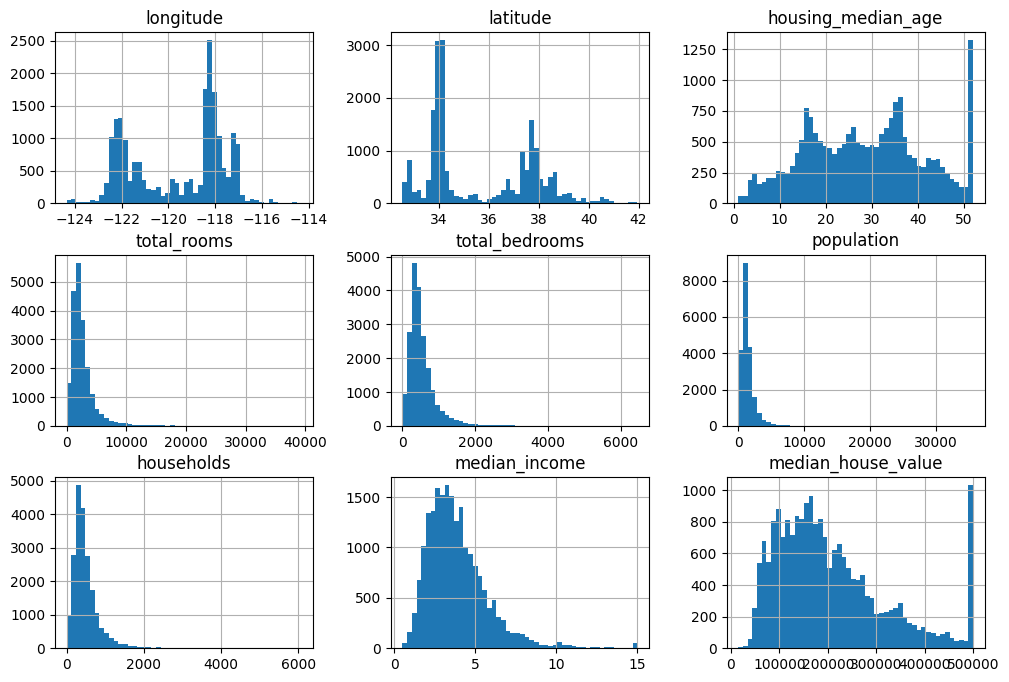

In [387]:
df.hist(bins=50, figsize=(12, 8), grid=True)
plt.show()

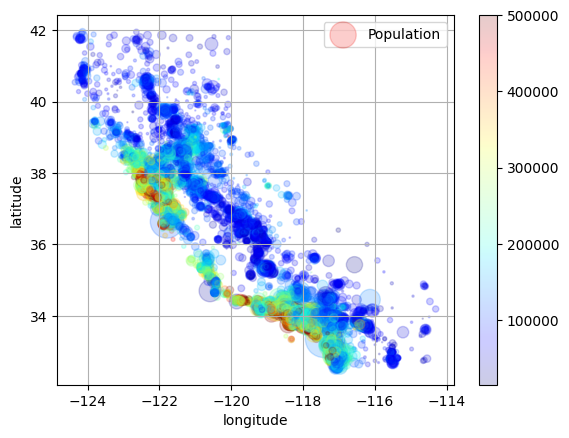

In [388]:
df.plot(kind='scatter', x='longitude', y='latitude', grid=True, alpha=0.2, c=df['median_house_value'], s=df['population']/50, colormap='jet', colorbar=True, label='Population', legend=True, sharex=False)
plt.show()

In [389]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


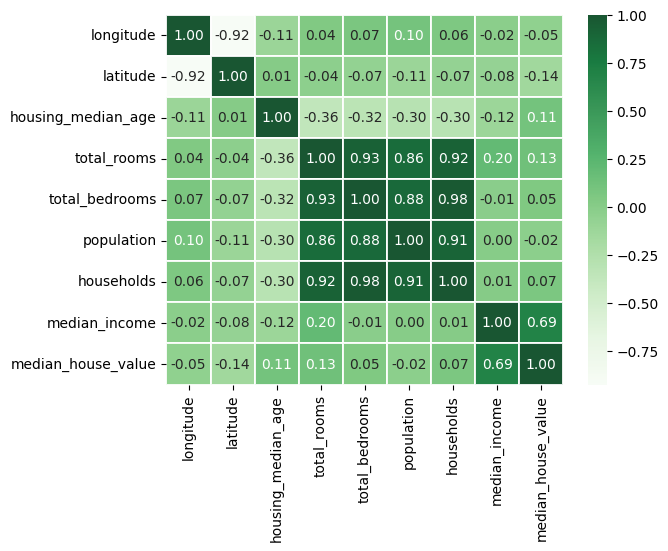

In [390]:
sns.heatmap(corr_matrix, cmap='Greens', alpha=0.9, annot=True, fmt=".2f", linewidths=0.1, linecolor='white')
plt.show()

In [391]:
attributes = df.select_dtypes(exclude='object').columns

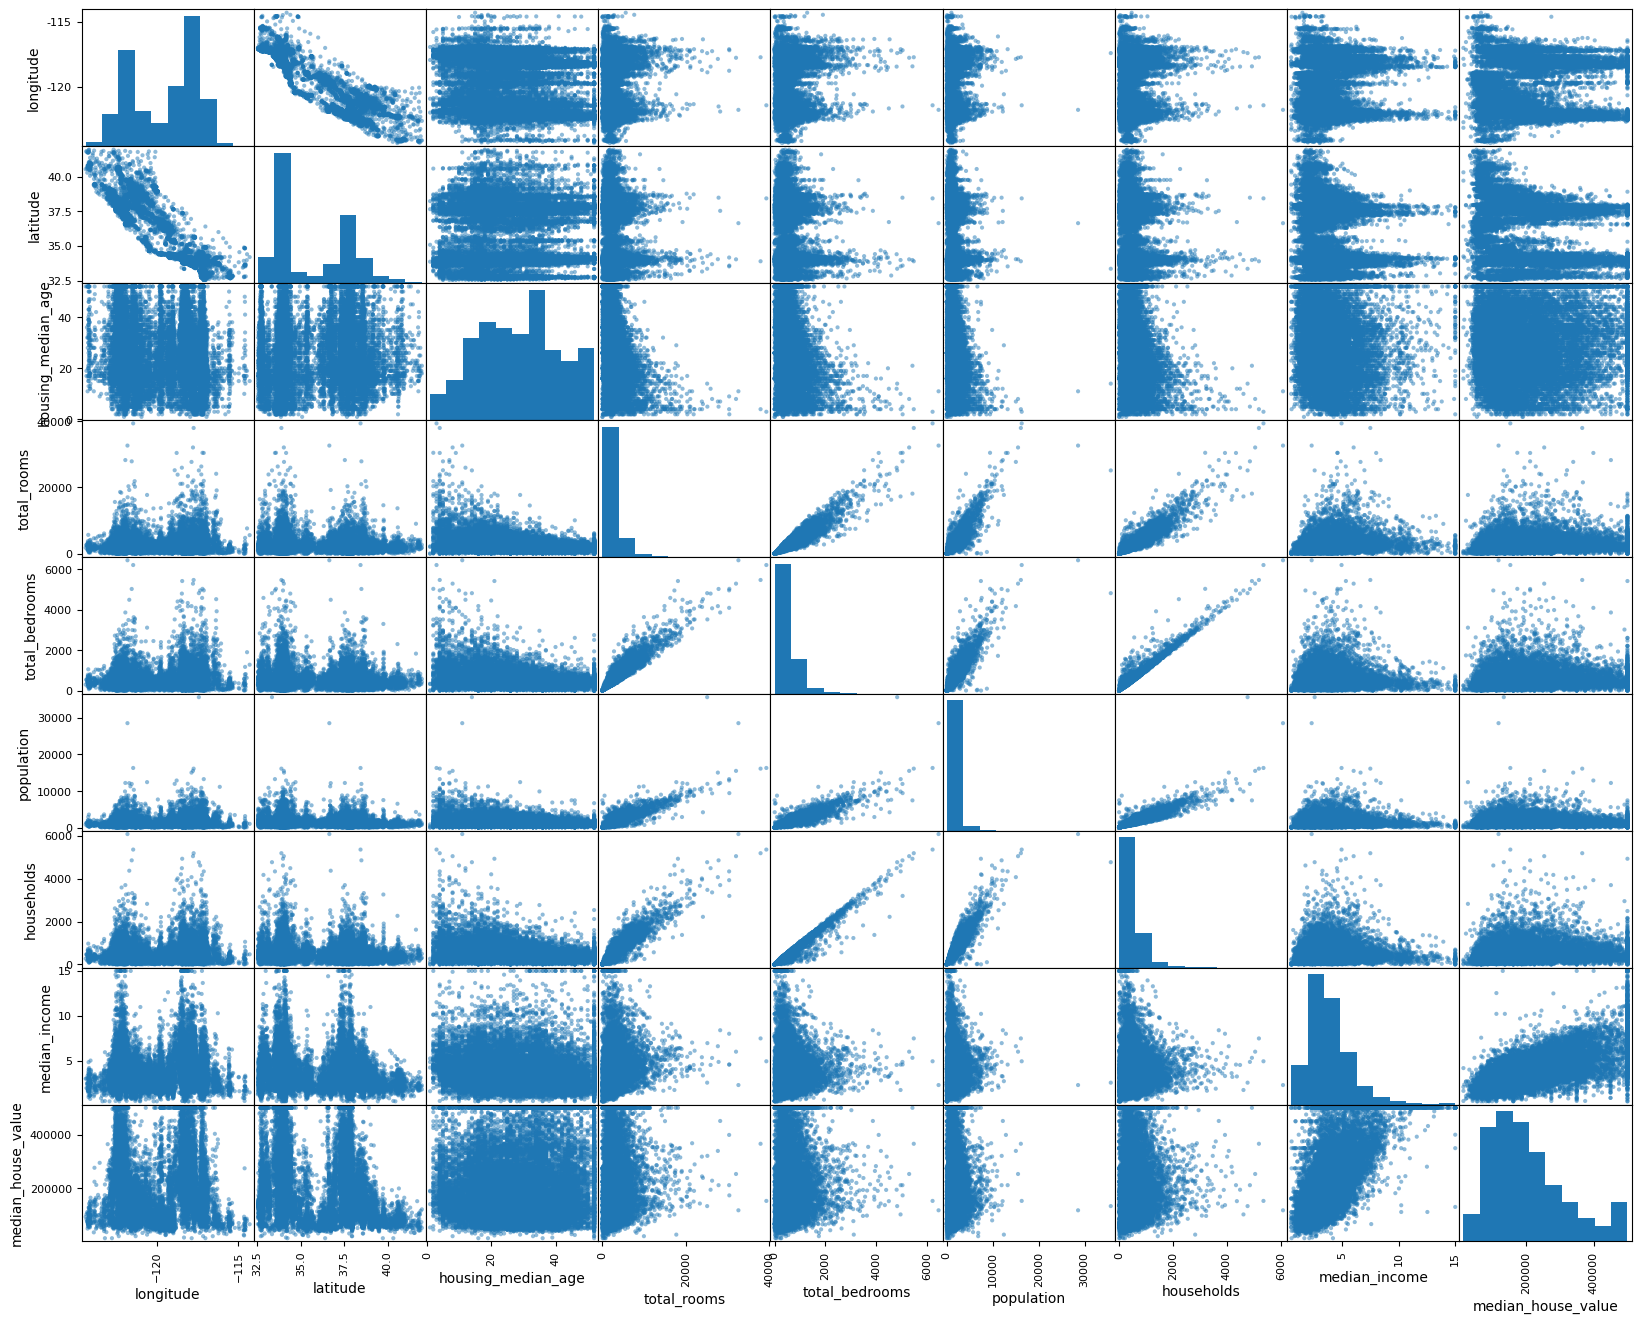

In [392]:
scatter_matrix(df[attributes], figsize=(20, 16))
plt.show()

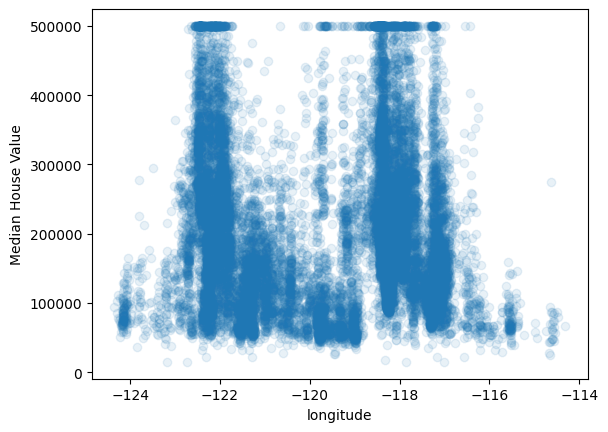

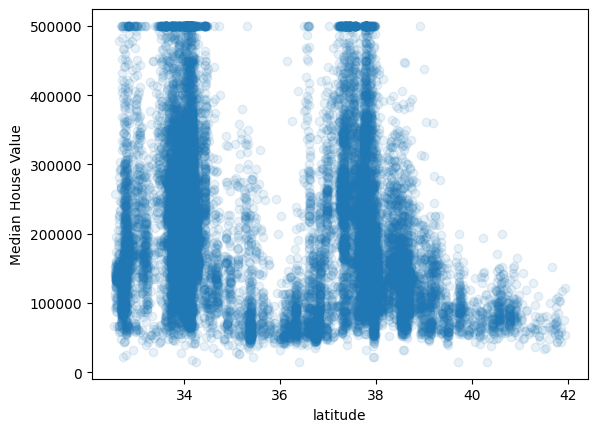

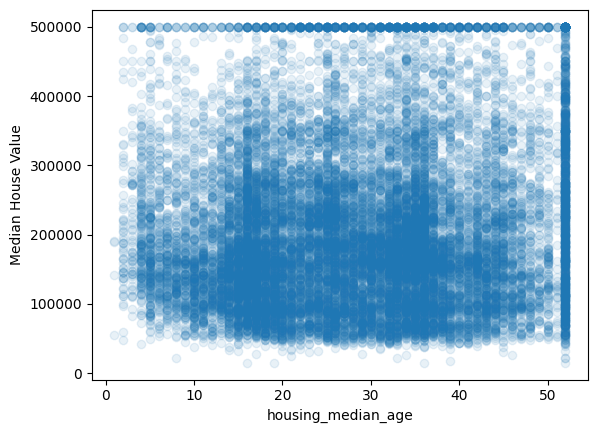

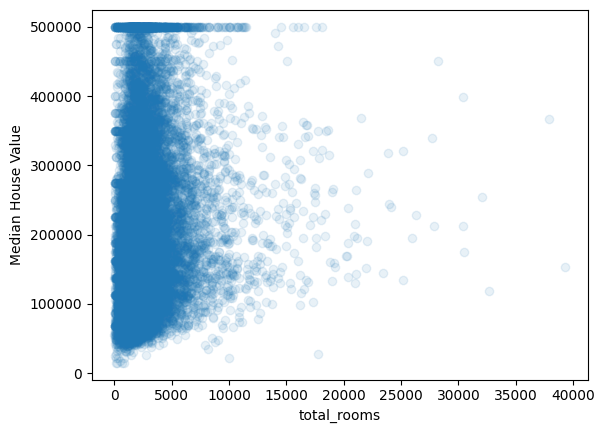

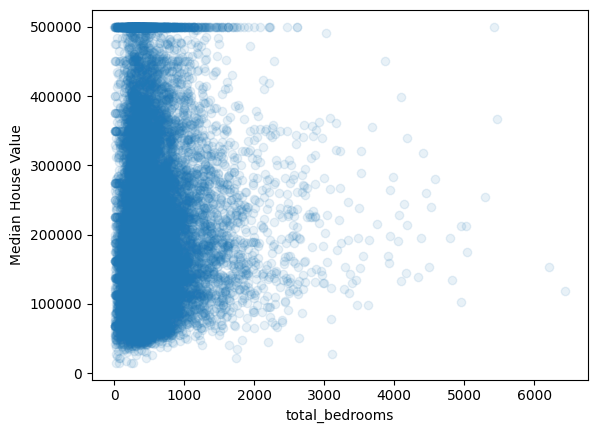

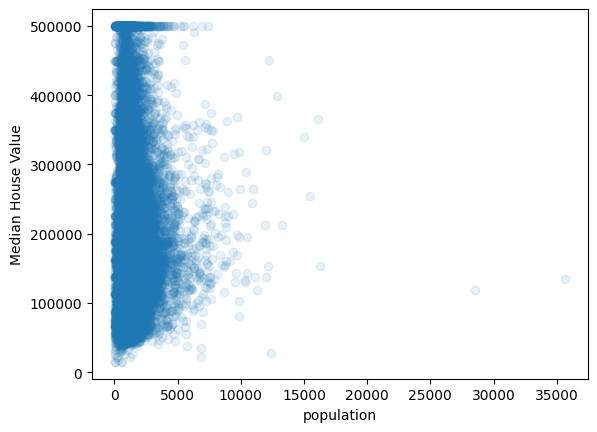

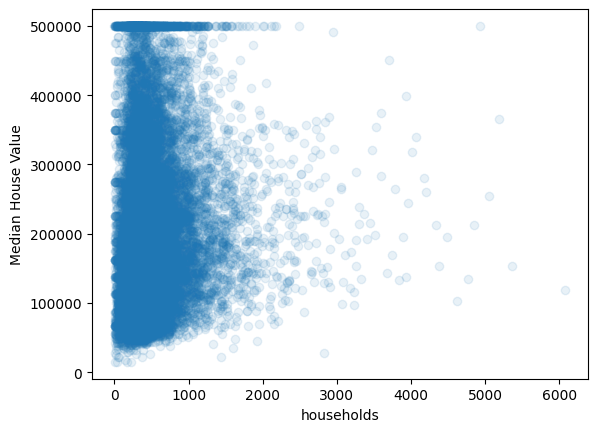

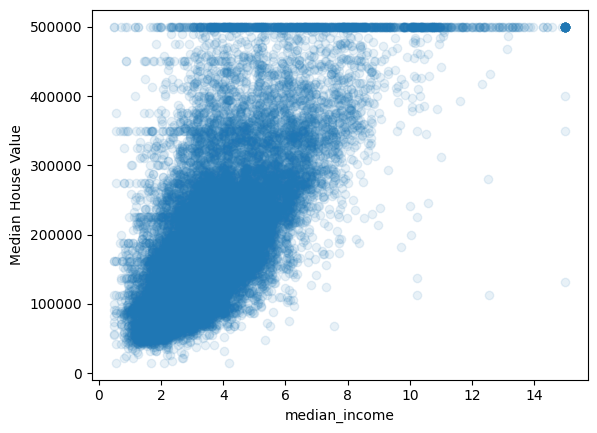

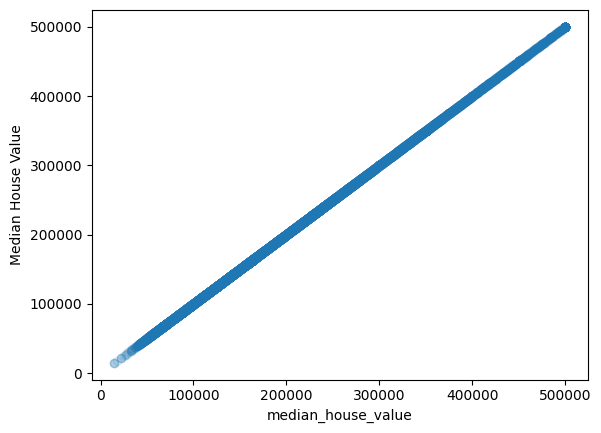

In [393]:
for each in attributes:
  plt.scatter(df[each], df['median_house_value'], alpha=0.1)
  plt.xlabel(f'{each}')
  plt.ylabel(f'Median House Value')
  plt.show()

# Feature Engineering

In [394]:
df['rooms_per_house'] = df['total_rooms']/df['households']
df['bedrooms_ratio'] = df['total_bedrooms']/df['total_rooms']
df['people_per_house'] = df['population']/df['households']

In [395]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_house,bedrooms_ratio,people_per_house
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [396]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
rooms_per_house,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
people_per_house,-0.023737
population,-0.024650
longitude,-0.045967


# Clean the Data & Pipelining

In [397]:
log_transform_pipeline = Pipeline([
    ('impute_num', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(func=np.log1p, inverse_func=np.expm1)), # Use log1p to handle zeros
    ('scaler', StandardScaler())
])

no_log_transform_pipeline = Pipeline([
    ('impute_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [398]:
cat_pipeline = Pipeline([
    ('impute_cat', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Prepare the Data

In [399]:
num_attribs_all = list(df.select_dtypes(include=['float64']).drop('median_house_value', axis=1).columns)
cat_attribs = ['ocean_proximity']

num_log_attribs = [
    'total_rooms', 'total_bedrooms', 'population', 'households',
    'median_income', 'rooms_per_house', 'bedrooms_ratio', 'people_per_house'
]
num_no_log_attribs = [col for col in num_attribs_all if col not in num_log_attribs]

In [400]:
preprocessor = ColumnTransformer([
    ('num_log', log_transform_pipeline, num_log_attribs),
    ('num_no_log', no_log_transform_pipeline, num_no_log_attribs),
    ('cat', cat_pipeline, cat_attribs),
])

In [401]:
display(preprocessor)

ColumnTransformer(transformers=[('num_log',
                                 Pipeline(steps=[('impute_num',
                                                  SimpleImputer(strategy='median')),
                                                 ('log1p',
                                                  FunctionTransformer(func=<ufunc 'log1p'>,
                                                                      inverse_func=<ufunc 'expm1'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income',
                                  'rooms_per_house', 'bedrooms_ratio',
                                  'people_per_house']),
                                ('num_no_log',
                                 Pipeline(steps=[('impute_num',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['longitude', 'latitude',
                                  'housing_median_age']),
                                ('cat',
                                 Pipeline(steps=[('impute_cat',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])

# Split Data into Training and Test Sets

In [402]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [403]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [404]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 12)
X_test shape: (4128, 12)
y_train shape: (16512,)
y_test shape: (4128,)


# Model Training and Prediction

## Linear Regression

In [405]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [406]:
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

### Cross Validation

In [407]:
lin_rmses = -cross_val_score(full_pipeline, X_train, y_train, scoring='neg_root_mean_squared_error', cv=10, verbose=3)

[CV] END ........................... score: (test=-67666.878) total time=   0.1s
[CV] END ........................... score: (test=-68242.690) total time=   0.1s
[CV] END ........................... score: (test=-67226.501) total time=   0.1s
[CV] END ........................... score: (test=-65948.415) total time=   0.1s
[CV] END ........................... score: (test=-69508.432) total time=   0.1s
[CV] END ........................... score: (test=-66407.933) total time=   0.1s
[CV] END ........................... score: (test=-67902.036) total time=   0.1s
[CV] END ........................... score: (test=-65854.141) total time=   0.1s
[CV] END ........................... score: (test=-68089.994) total time=   0.1s
[CV] END ........................... score: (test=-67375.715) total time=   0.1s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    0.9s finished


In [408]:
lin_reg_cv = pd.Series(lin_rmses).describe()

In [409]:
lin_reg_cv

,0
count,10.000000
mean,67422.273679
std,1128.503074
min,65854.141422
25%,66612.575111
50%,67521.296775
75%,68043.004677
max,69508.431881


### Measuring Performance

In [410]:
lin_mse = mean_squared_error(y_test, y_pred)
lin_rmse = np.sqrt(lin_mse)
lin_r2 = r2_score(y_test, y_pred)

In [411]:
print(f"Mean Squared Error (MSE): {lin_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {lin_rmse:.2f}")
print(f"R-squared (R2): {lin_r2:.2f}")

Mean Squared Error (MSE): 4728932825.93
Root Mean Squared Error (RMSE): 68767.24
R-squared (R2): 0.66


## Decision Tree Regressor

In [412]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor())
])

In [413]:
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

### Cross Validation

In [414]:
tree_rmses = -cross_val_score(full_pipeline, X_train, y_train, scoring='neg_root_mean_squared_error', cv=10, verbose=3)

[CV] END ........................... score: (test=-69609.009) total time=   0.4s
[CV] END ........................... score: (test=-70750.512) total time=   0.5s
[CV] END ........................... score: (test=-69027.464) total time=   0.4s
[CV] END ........................... score: (test=-66535.942) total time=   0.4s
[CV] END ........................... score: (test=-69465.830) total time=   0.5s
[CV] END ........................... score: (test=-67098.054) total time=   0.5s
[CV] END ........................... score: (test=-71174.170) total time=   0.4s
[CV] END ........................... score: (test=-70800.678) total time=   0.4s
[CV] END ........................... score: (test=-72825.254) total time=   0.4s
[CV] END ........................... score: (test=-67423.036) total time=   0.4s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:    4.5s finished


In [415]:
tree_reg_cv = pd.Series(tree_rmses).describe()

In [416]:
tree_reg_cv

,0
count,10.000000
mean,69470.994935
std,2005.891239
min,66535.941527
25%,67824.143205
50%,69537.419508
75%,70788.136537
max,72825.253883


### Measuring Performance

In [417]:
tree_mse = mean_squared_error(y_test, y_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, y_pred)

In [418]:
print(f"Mean Squared Error (MSE): {tree_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {tree_rmse:.2f}")
print(f"R-squared (R2): {tree_r2:.2f}")

Mean Squared Error (MSE): 5300290093.16
Root Mean Squared Error (RMSE): 72803.09
R-squared (R2): 0.62


## Random Forest Regressor

In [419]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [420]:
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

### Cross Validation

In [421]:
forest_rmses = -cross_val_score(full_pipeline, X_train, y_train, scoring='neg_root_mean_squared_error', cv=10, verbose=3)

[CV] END ........................... score: (test=-49158.409) total time=  27.5s
[CV] END ........................... score: (test=-49398.879) total time=  27.3s
[CV] END ........................... score: (test=-49708.611) total time=  27.4s
[CV] END ........................... score: (test=-48552.032) total time=  27.6s
[CV] END ........................... score: (test=-51334.489) total time=  27.5s
[CV] END ........................... score: (test=-48485.763) total time=  28.0s
[CV] END ........................... score: (test=-50175.824) total time=  27.8s
[CV] END ........................... score: (test=-48863.782) total time=  27.3s
[CV] END ........................... score: (test=-49921.630) total time=  27.3s
[CV] END ........................... score: (test=-49582.153) total time=  27.5s


[Parallel(n_jobs=1)]: Done  10 out of  10 | elapsed:  4.6min finished


In [422]:
forest_reg_cv = pd.Series(forest_rmses).describe()

In [423]:
forest_reg_cv

,0
count,10.000000
mean,49518.157182
std,850.217903
min,48485.763128
25%,48937.438559
50%,49490.515835
75%,49868.374985
max,51334.489061


### Measuring Performance

In [424]:
forest_mse = mean_squared_error(y_test, y_pred)
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, y_pred)

In [425]:
print(f"Mean Squared Error (MSE): {forest_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {forest_rmse:.2f}")
print(f"R-squared (R2): {forest_r2:.2f}")

Mean Squared Error (MSE): 2576114517.59
Root Mean Squared Error (RMSE): 50755.44
R-squared (R2): 0.81


# GridSearch CV

In [426]:
param_grid=[
    {
        'regressor__n_estimators' : [10, 50, 100, 150],
        'regressor__max_depth': [None, 10, 20],
        'regressor__max_features' : [6, 8, 10]
    }
]

In [428]:
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=3,
    verbose=3,
    scoring='neg_root_mean_squared_error'
)

In [429]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV 1/3] END regressor__max_depth=None, regressor__max_features=6, regressor__n_estimators=10;, score=-52636.786 total time=   0.8s
[CV 2/3] END regressor__max_depth=None, regressor__max_features=6, regressor__n_estimators=10;, score=-52584.347 total time=   0.8s
[CV 3/3] END regressor__max_depth=None, regressor__max_features=6, regressor__n_estimators=10;, score=-51617.787 total time=   0.8s
[CV 1/3] END regressor__max_depth=None, regressor__max_features=6, regressor__n_estimators=50;, score=-49343.772 total time=   4.7s
[CV 2/3] END regressor__max_depth=None, regressor__max_features=6, regressor__n_estimators=50;, score=-49925.945 total time=   3.9s
[CV 3/3] END regressor__max_depth=None, regressor__max_features=6, regressor__n_estimators=50;, score=-49336.247 total time=   3.9s
[CV 1/3] END regressor__max_depth=None, regressor__max_features=6, regressor__n_estimators=100;, score=-49171.128 total time=   8.5s
[CV 2/3] END 

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num_log',
                                                                         Pipeline(steps=[('impute_num',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('log1p',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                                              inverse_func=<ufunc 'expm1'>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income',...
                                                                         Pipeline(steps=[('impute_cat',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'regressor__max_depth': [None, 10, 20],
                          'regressor__max_features': [6, 8, 10],
                          'regressor__n_estimators': [10, 50, 100, 150]}],
             scoring='neg_root_mean_squared_error', verbose=3)

In [430]:
grid_search.best_params_

{'regressor__max_depth': None,
 'regressor__max_features': 6,
 'regressor__n_estimators': 150}

In [432]:
best_model = grid_search.best_estimator_

In [436]:
y_pred = best_model.predict(X_test)

In [437]:
best_mse = mean_squared_error(y_test, y_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, y_pred)

In [438]:
print(f"Mean Squared Error (MSE): {best_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {best_rmse:.2f}")
print(f"R-squared (R2): {best_r2:.2f}")

Mean Squared Error (MSE): 2395701945.75
Root Mean Squared Error (RMSE): 48945.91
R-squared (R2): 0.83


# Save the Model

In [440]:
joblib.dump(best_model, 'housing_model.pkl')

['housing_model.pkl']